In [ ]:
# Title: 02_Ripa_ElasticNet.ipynb
# Author: Lajoyce Mboning
# Edited by: Emma K. Costa
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the EN clock on Ripa et al

# Set Up

In [ ]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import LeaveOneOut
from scipy.stats import ttest_ind, mannwhitneyu

In [ ]:
#allow Google CoLab to have access to your drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# set working dir
# Get current notebook's directory
notebook_dir = '/content/drive/My Drive/african_killifish_atlas/revisions/CodeCheck_revisions/Ripa_model_outputs/ElasticNet/'

# Set working directory (here it's just confirming it's already set)
os.chdir(notebook_dir)

# Load and format intervention data

In [ ]:
df = pd.read_csv("../../Data_from_Others/Antebi_Fat_Ripa_etal_2023/CountsNormDESeq2_AntebiFat_250605.csv")

df.head(5)

,Unnamed: 0,young_fed_wt_fat_rep_4,young_fasted_wt_fat_rep_1,young_fasted_wt_fat_rep_2,young_fasted_wt_fat_rep_3,young_fasted_wt_fat_rep_4,young_fed_mut_fat_rep_1,young_fed_mut_fat_rep_2,old_fed_wt_fat_rep_4,young_fed_mut_fat_rep_3,...,old_fasted_mut_fat_rep_3,old_fasted_mut_fat_rep_2,old_fasted_mut_fat_rep_1,old_fed_mut_fat_rep_5,old_fed_mut_fat_rep_4,old_fed_mut_fat_rep_3,old_fed_mut_fat_rep_2,old_fed_mut_fat_rep_1,old_fed_wt_fat_rep_2,old_fed_wt_fat_rep_1
0,LOC107389033,36.053243,72.526712,49.392975,78.809091,67.473420,107.261815,69.336963,287.925564,87.207925,...,231.054531,252.187117,115.224356,93.909833,145.647969,129.180120,91.235722,139.159652,273.443432,228.423958
1,LOC107383083,0.000000,9.460006,0.000000,2.814610,8.434177,11.290717,0.000000,0.000000,2.076379,...,5.705050,18.880319,19.338354,0.000000,6.132546,18.631748,13.617272,3.115515,3.811058,2.864250
2,LOC107396907,18.026622,60.701705,66.425035,77.401786,74.501901,183.474157,137.903515,140.292343,115.239044,...,184.273120,128.116450,82.993767,58.197643,154.846788,80.737575,125.278901,114.235536,212.466499,90.223883
3,LOC107392678,9.013311,18.920012,17.032060,8.443831,22.491140,11.290717,13.867393,14.681757,10.381896,...,21.108686,24.274696,12.892236,5.290695,12.265092,24.842331,19.064181,16.616078,23.819114,12.889126
4,LOC107395313,33.799916,31.533353,37.470533,49.255682,36.548102,38.106171,33.898071,34.257433,25.954740,...,35.371311,29.669073,55.597766,40.341548,52.893210,40.989846,32.681453,33.751408,34.299525,30.790690


In [ ]:
df.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df.head(5)

,sample,young_fed_wt_fat_rep_4,young_fasted_wt_fat_rep_1,young_fasted_wt_fat_rep_2,young_fasted_wt_fat_rep_3,young_fasted_wt_fat_rep_4,young_fed_mut_fat_rep_1,young_fed_mut_fat_rep_2,old_fed_wt_fat_rep_4,young_fed_mut_fat_rep_3,...,old_fasted_mut_fat_rep_3,old_fasted_mut_fat_rep_2,old_fasted_mut_fat_rep_1,old_fed_mut_fat_rep_5,old_fed_mut_fat_rep_4,old_fed_mut_fat_rep_3,old_fed_mut_fat_rep_2,old_fed_mut_fat_rep_1,old_fed_wt_fat_rep_2,old_fed_wt_fat_rep_1
0,LOC107389033,36.053243,72.526712,49.392975,78.809091,67.473420,107.261815,69.336963,287.925564,87.207925,...,231.054531,252.187117,115.224356,93.909833,145.647969,129.180120,91.235722,139.159652,273.443432,228.423958
1,LOC107383083,0.000000,9.460006,0.000000,2.814610,8.434177,11.290717,0.000000,0.000000,2.076379,...,5.705050,18.880319,19.338354,0.000000,6.132546,18.631748,13.617272,3.115515,3.811058,2.864250
2,LOC107396907,18.026622,60.701705,66.425035,77.401786,74.501901,183.474157,137.903515,140.292343,115.239044,...,184.273120,128.116450,82.993767,58.197643,154.846788,80.737575,125.278901,114.235536,212.466499,90.223883
3,LOC107392678,9.013311,18.920012,17.032060,8.443831,22.491140,11.290717,13.867393,14.681757,10.381896,...,21.108686,24.274696,12.892236,5.290695,12.265092,24.842331,19.064181,16.616078,23.819114,12.889126
4,LOC107395313,33.799916,31.533353,37.470533,49.255682,36.548102,38.106171,33.898071,34.257433,25.954740,...,35.371311,29.669073,55.597766,40.341548,52.893210,40.989846,32.681453,33.751408,34.299525,30.790690


In [ ]:
df.set_index("sample", inplace=True)

df.head(5)

,young_fed_wt_fat_rep_4,young_fasted_wt_fat_rep_1,young_fasted_wt_fat_rep_2,young_fasted_wt_fat_rep_3,young_fasted_wt_fat_rep_4,young_fed_mut_fat_rep_1,young_fed_mut_fat_rep_2,old_fed_wt_fat_rep_4,young_fed_mut_fat_rep_3,young_fed_mut_fat_rep_4,...,old_fasted_mut_fat_rep_3,old_fasted_mut_fat_rep_2,old_fasted_mut_fat_rep_1,old_fed_mut_fat_rep_5,old_fed_mut_fat_rep_4,old_fed_mut_fat_rep_3,old_fed_mut_fat_rep_2,old_fed_mut_fat_rep_1,old_fed_wt_fat_rep_2,old_fed_wt_fat_rep_1
sample,,,,,,,,,,,,,,,,,,,,,
LOC107389033,36.053243,72.526712,49.392975,78.809091,67.473420,107.261815,69.336963,287.925564,87.207925,61.512917,...,231.054531,252.187117,115.224356,93.909833,145.647969,129.180120,91.235722,139.159652,273.443432,228.423958
LOC107383083,0.000000,9.460006,0.000000,2.814610,8.434177,11.290717,0.000000,0.000000,2.076379,0.000000,...,5.705050,18.880319,19.338354,0.000000,6.132546,18.631748,13.617272,3.115515,3.811058,2.864250
LOC107396907,18.026622,60.701705,66.425035,77.401786,74.501901,183.474157,137.903515,140.292343,115.239044,120.408264,...,184.273120,128.116450,82.993767,58.197643,154.846788,80.737575,125.278901,114.235536,212.466499,90.223883
LOC107392678,9.013311,18.920012,17.032060,8.443831,22.491140,11.290717,13.867393,14.681757,10.381896,15.705426,...,21.108686,24.274696,12.892236,5.290695,12.265092,24.842331,19.064181,16.616078,23.819114,12.889126
LOC107395313,33.799916,31.533353,37.470533,49.255682,36.548102,38.106171,33.898071,34.257433,25.954740,31.410851,...,35.371311,29.669073,55.597766,40.341548,52.893210,40.989846,32.681453,33.751408,34.299525,30.790690


In [ ]:
df = df.T

df.head(5)

sample,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107397194,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320
young_fed_wt_fat_rep_4,36.053243,0.000000,18.026622,9.013311,33.799916,0.000000,184.772872,196.039510,74.359814,588.118530,...,286.172618,721.064864,0.000000,0.000000,130.693007,36.053243,883.304459,554.318615,290.679273,15.773294
young_fasted_wt_fat_rep_1,72.526712,9.460006,60.701705,18.920012,31.533353,7.883338,178.163445,89.870057,76.468381,316.910199,...,359.480226,714.230449,11.825007,39.416691,194.718456,138.746754,789.122163,346.078551,223.098474,51.241699
young_fasted_wt_fat_rep_2,49.392975,0.000000,66.425035,17.032060,37.470533,10.219236,218.010373,117.521217,124.334041,456.459218,...,488.820133,1161.586518,0.000000,0.000000,68.128242,139.662895,911.215230,614.857380,124.334041,10.219236
young_fasted_wt_fat_rep_3,78.809091,2.814610,77.401786,8.443831,49.255682,2.814610,208.281169,92.882143,121.028247,343.382468,...,454.559578,1007.630519,0.000000,0.000000,111.177110,95.696753,966.818669,640.323864,177.320455,84.438312
young_fasted_wt_fat_rep_4,67.473420,8.434177,74.501901,22.491140,36.548102,5.622785,220.694310,113.861396,116.672788,479.342419,...,323.310136,974.147497,0.000000,4.217089,53.416457,108.238611,833.577873,463.879761,164.466461,30.925317


In [ ]:
df_metadata = pd.read_csv("../../Data_from_Others/Antebi_Fat_Ripa_etal_2023/ExperimentDesign_AntebiFat_update.csv")

df_metadata.head(5)

,Sample.Name,Run,AGE,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,...,Platform,ReleaseDate,create_date,version,sex,SRA.Study,strain,tissue,file,lib
0,young_fed_wt_fat_rep_4,SRR18362991,Young (7 weeks),RNA-Seq,202,6623920370,PRJNA817434,SAMN26788046,Model organism or animal,1964305779,...,ILLUMINA,2022-03-20T00:00:00Z,2022-03-20T03:18:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362991.featureCounts,SRR18362991
1,young_fasted_wt_fat_rep_1,SRR18362992,Young (7 weeks),RNA-Seq,202,7410627954,PRJNA817434,SAMN26788047,Model organism or animal,2234922451,...,ILLUMINA,2022-03-20T00:00:00Z,2022-03-20T03:46:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362992.featureCounts,SRR18362992
2,young_fasted_wt_fat_rep_2,SRR18362993,Young (7 weeks),RNA-Seq,202,6127879272,PRJNA817434,SAMN26788048,Model organism or animal,1868755404,...,ILLUMINA,2022-03-20T00:00:00Z,2022-03-20T03:13:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362993.featureCounts,SRR18362993
3,young_fasted_wt_fat_rep_3,SRR18362994,Young (7 weeks),RNA-Seq,202,7087796402,PRJNA817434,SAMN26788049,Model organism or animal,2137039468,...,ILLUMINA,2022-03-20T00:00:00Z,2022-03-20T03:58:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362994.featureCounts,SRR18362994
4,young_fasted_wt_fat_rep_4,SRR18362995,Young (7 weeks),RNA-Seq,202,6103246988,PRJNA817434,SAMN26788050,Model organism or animal,1833695494,...,ILLUMINA,2022-03-20T00:00:00Z,2022-03-20T03:22:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362995.featureCounts,SRR18362995


In [ ]:
df_metadata.set_index("Sample.Name", inplace=True)

df_metadata.head(5)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center.Name,...,Platform,ReleaseDate,create_date,version,sex,SRA.Study,strain,tissue,file,lib
Sample.Name,,,,,,,,,,,,,,,,,,,,,
young_fed_wt_fat_rep_4,SRR18362991,Young (7 weeks),RNA-Seq,202,6623920370,PRJNA817434,SAMN26788046,Model organism or animal,1964305779,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,ILLUMINA,2022-03-20T00:00:00Z,2022-03-20T03:18:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362991.featureCounts,SRR18362991
young_fasted_wt_fat_rep_1,SRR18362992,Young (7 weeks),RNA-Seq,202,7410627954,PRJNA817434,SAMN26788047,Model organism or animal,2234922451,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,ILLUMINA,2022-03-20T00:00:00Z,2022-03-20T03:46:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362992.featureCounts,SRR18362992
young_fasted_wt_fat_rep_2,SRR18362993,Young (7 weeks),RNA-Seq,202,6127879272,PRJNA817434,SAMN26788048,Model organism or animal,1868755404,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,ILLUMINA,2022-03-20T00:00:00Z,2022-03-20T03:13:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362993.featureCounts,SRR18362993
young_fasted_wt_fat_rep_3,SRR18362994,Young (7 weeks),RNA-Seq,202,7087796402,PRJNA817434,SAMN26788049,Model organism or animal,2137039468,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,ILLUMINA,2022-03-20T00:00:00Z,2022-03-20T03:58:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362994.featureCounts,SRR18362994
young_fasted_wt_fat_rep_4,SRR18362995,Young (7 weeks),RNA-Seq,202,6103246988,PRJNA817434,SAMN26788050,Model organism or animal,1833695494,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,ILLUMINA,2022-03-20T00:00:00Z,2022-03-20T03:22:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362995.featureCounts,SRR18362995


In [ ]:
df_metadata.columns

Index(['Run', 'AGE', 'Assay.Type', 'AvgSpotLen', 'Bases', 'BioProject',
       'BioSample', 'BioSampleModel', 'Bytes', 'Center.Name', 'Consent',
       'DATASTORE.filetype', 'DATASTORE.provider', 'DATASTORE.region',
       'Experiment', 'Instrument', 'isolate', 'Library.Name', 'LibraryLayout',
       'LibrarySelection', 'LibrarySource', 'Organism', 'Platform',
       'ReleaseDate', 'create_date', 'version', 'sex', 'SRA.Study', 'strain',
       'tissue', 'file', 'lib'],
      dtype='object')

In [ ]:
df_metadata["tissue"].value_counts()

tissue
Visceral adipose tissue    36
Name: count, dtype: int64

In [ ]:
df_metadata["sex"].value_counts()

sex
male    36
Name: count, dtype: int64

In [ ]:
df_metadata.index.dtype

dtype('O')

In [ ]:
df_metadata.index.tolist()

['young_fed_wt_fat_rep_4',
 'young_fasted_wt_fat_rep_1',
 'young_fasted_wt_fat_rep_2',
 'young_fasted_wt_fat_rep_3',
 'young_fasted_wt_fat_rep_4',
 'young_fed_mut_fat_rep_1',
 'young_fed_mut_fat_rep_2',
 'old_fed_wt_fat_rep_4',
 'young_fed_mut_fat_rep_3',
 'young_fed_mut_fat_rep_4',
 'young_fasted_mut_fat_rep_1',
 'young_fasted_mut_fat_rep_2',
 'young_fasted_mut_fat_rep_3',
 'young_fasted_mut_fat_rep_4',
 'old_fed_wt_fat_rep_5',
 'old_fasted_wt_fat_rep_1',
 'old_fasted_wt_fat_rep_2',
 'old_fasted_wt_fat_rep_3',
 'old_fasted_wt_fat_rep_4',
 'old_fasted_wt_fat_rep_5',
 'old_fed_wt_fat_rep_3',
 'young_fed_wt_fat_rep_1',
 'young_fed_wt_fat_rep_2',
 'young_fed_wt_fat_rep_3',
 'old_fasted_mut_fat_rep_5',
 'old_fasted_mut_fat_rep_4',
 'old_fasted_mut_fat_rep_3',
 'old_fasted_mut_fat_rep_2',
 'old_fasted_mut_fat_rep_1',
 'old_fed_mut_fat_rep_5',
 'old_fed_mut_fat_rep_4',
 'old_fed_mut_fat_rep_3',
 'old_fed_mut_fat_rep_2',
 'old_fed_mut_fat_rep_1',
 'old_fed_wt_fat_rep_2',
 'old_fed_wt_fat_rep_

In [ ]:
index_series = pd.Series(df_metadata.index, index=df_metadata.index).astype(str)

df_metadata['age'] = index_series.str.extract(r'^(young|old)')
df_metadata['feeding'] = index_series.str.extract(r'_(fed|fasted)_')
df_metadata['genotype'] = index_series.str.extract(r'_(wt|mut)_')

df_metadata.head(5)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center.Name,...,version,sex,SRA.Study,strain,tissue,file,lib,age,feeding,genotype
Sample.Name,,,,,,,,,,,,,,,,,,,,,
young_fed_wt_fat_rep_4,SRR18362991,Young (7 weeks),RNA-Seq,202,6623920370,PRJNA817434,SAMN26788046,Model organism or animal,1964305779,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362991.featureCounts,SRR18362991,young,fed,wt
young_fasted_wt_fat_rep_1,SRR18362992,Young (7 weeks),RNA-Seq,202,7410627954,PRJNA817434,SAMN26788047,Model organism or animal,2234922451,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362992.featureCounts,SRR18362992,young,fasted,wt
young_fasted_wt_fat_rep_2,SRR18362993,Young (7 weeks),RNA-Seq,202,6127879272,PRJNA817434,SAMN26788048,Model organism or animal,1868755404,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362993.featureCounts,SRR18362993,young,fasted,wt
young_fasted_wt_fat_rep_3,SRR18362994,Young (7 weeks),RNA-Seq,202,7087796402,PRJNA817434,SAMN26788049,Model organism or animal,2137039468,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362994.featureCounts,SRR18362994,young,fasted,wt
young_fasted_wt_fat_rep_4,SRR18362995,Young (7 weeks),RNA-Seq,202,6103246988,PRJNA817434,SAMN26788050,Model organism or animal,1833695494,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362995.featureCounts,SRR18362995,young,fasted,wt


In [ ]:
df_metadata_young = df_metadata[df_metadata["age"] == "young"]

df_metadata_young.head(3)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center.Name,...,version,sex,SRA.Study,strain,tissue,file,lib,age,feeding,genotype
Sample.Name,,,,,,,,,,,,,,,,,,,,,
young_fed_wt_fat_rep_4,SRR18362991,Young (7 weeks),RNA-Seq,202,6623920370,PRJNA817434,SAMN26788046,Model organism or animal,1964305779,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362991.featureCounts,SRR18362991,young,fed,wt
young_fasted_wt_fat_rep_1,SRR18362992,Young (7 weeks),RNA-Seq,202,7410627954,PRJNA817434,SAMN26788047,Model organism or animal,2234922451,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362992.featureCounts,SRR18362992,young,fasted,wt
young_fasted_wt_fat_rep_2,SRR18362993,Young (7 weeks),RNA-Seq,202,6127879272,PRJNA817434,SAMN26788048,Model organism or animal,1868755404,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362993.featureCounts,SRR18362993,young,fasted,wt


In [ ]:
df_metadata_young["feeding"].value_counts()

feeding
fed       8
fasted    8
Name: count, dtype: int64

In [ ]:
df_metadata["AGE"].value_counts()

AGE
Old (18 weeks)     20
Young (7 weeks)    16
Name: count, dtype: int64

In [ ]:
df_metadata["sex"].value_counts()

sex
male    36
Name: count, dtype: int64

In [ ]:
# Map weeks to days: old = 18 weeks = 126 days, young = 7 weeks = 49 days
age_to_days = {'old': 126, 'young': 49}

# Create the 'days' column
df_metadata['days'] = df_metadata['age'].map(age_to_days)

In [ ]:
df_metadata.head(5)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center.Name,...,sex,SRA.Study,strain,tissue,file,lib,age,feeding,genotype,days
Sample.Name,,,,,,,,,,,,,,,,,,,,,
young_fed_wt_fat_rep_4,SRR18362991,Young (7 weeks),RNA-Seq,202,6623920370,PRJNA817434,SAMN26788046,Model organism or animal,1964305779,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362991.featureCounts,SRR18362991,young,fed,wt,49
young_fasted_wt_fat_rep_1,SRR18362992,Young (7 weeks),RNA-Seq,202,7410627954,PRJNA817434,SAMN26788047,Model organism or animal,2234922451,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362992.featureCounts,SRR18362992,young,fasted,wt,49
young_fasted_wt_fat_rep_2,SRR18362993,Young (7 weeks),RNA-Seq,202,6127879272,PRJNA817434,SAMN26788048,Model organism or animal,1868755404,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362993.featureCounts,SRR18362993,young,fasted,wt,49
young_fasted_wt_fat_rep_3,SRR18362994,Young (7 weeks),RNA-Seq,202,7087796402,PRJNA817434,SAMN26788049,Model organism or animal,2137039468,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362994.featureCounts,SRR18362994,young,fasted,wt,49
young_fasted_wt_fat_rep_4,SRR18362995,Young (7 weeks),RNA-Seq,202,6103246988,PRJNA817434,SAMN26788050,Model organism or animal,1833695494,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362995.featureCounts,SRR18362995,young,fasted,wt,49


In [ ]:
df_metadata = df_metadata.loc[df.index.tolist(), ]

df_metadata.head(5)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center.Name,...,sex,SRA.Study,strain,tissue,file,lib,age,feeding,genotype,days
Sample.Name,,,,,,,,,,,,,,,,,,,,,
young_fed_wt_fat_rep_4,SRR18362991,Young (7 weeks),RNA-Seq,202,6623920370,PRJNA817434,SAMN26788046,Model organism or animal,1964305779,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362991.featureCounts,SRR18362991,young,fed,wt,49
young_fasted_wt_fat_rep_1,SRR18362992,Young (7 weeks),RNA-Seq,202,7410627954,PRJNA817434,SAMN26788047,Model organism or animal,2234922451,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362992.featureCounts,SRR18362992,young,fasted,wt,49
young_fasted_wt_fat_rep_2,SRR18362993,Young (7 weeks),RNA-Seq,202,6127879272,PRJNA817434,SAMN26788048,Model organism or animal,1868755404,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362993.featureCounts,SRR18362993,young,fasted,wt,49
young_fasted_wt_fat_rep_3,SRR18362994,Young (7 weeks),RNA-Seq,202,7087796402,PRJNA817434,SAMN26788049,Model organism or animal,2137039468,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362994.featureCounts,SRR18362994,young,fasted,wt,49
young_fasted_wt_fat_rep_4,SRR18362995,Young (7 weeks),RNA-Seq,202,6103246988,PRJNA817434,SAMN26788050,Model organism or animal,1833695494,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362995.featureCounts,SRR18362995,young,fasted,wt,49


In [ ]:
df_metadata["AGE"].value_counts()

AGE
Old (18 weeks)     20
Young (7 weeks)    16
Name: count, dtype: int64

In [ ]:
antebi_age = df.copy()

antebi_age["age"] = df_metadata["days"].tolist()

antebi_age.head(5)

sample,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320,age
young_fed_wt_fat_rep_4,36.053243,0.000000,18.026622,9.013311,33.799916,0.000000,184.772872,196.039510,74.359814,588.118530,...,721.064864,0.000000,0.000000,130.693007,36.053243,883.304459,554.318615,290.679273,15.773294,49
young_fasted_wt_fat_rep_1,72.526712,9.460006,60.701705,18.920012,31.533353,7.883338,178.163445,89.870057,76.468381,316.910199,...,714.230449,11.825007,39.416691,194.718456,138.746754,789.122163,346.078551,223.098474,51.241699,49
young_fasted_wt_fat_rep_2,49.392975,0.000000,66.425035,17.032060,37.470533,10.219236,218.010373,117.521217,124.334041,456.459218,...,1161.586518,0.000000,0.000000,68.128242,139.662895,911.215230,614.857380,124.334041,10.219236,49
young_fasted_wt_fat_rep_3,78.809091,2.814610,77.401786,8.443831,49.255682,2.814610,208.281169,92.882143,121.028247,343.382468,...,1007.630519,0.000000,0.000000,111.177110,95.696753,966.818669,640.323864,177.320455,84.438312,49
young_fasted_wt_fat_rep_4,67.473420,8.434177,74.501901,22.491140,36.548102,5.622785,220.694310,113.861396,116.672788,479.342419,...,974.147497,0.000000,4.217089,53.416457,108.238611,833.577873,463.879761,164.466461,30.925317,49


# Atlas

In [ ]:
df_norm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/CountsNormDESeq2_AllTissue_240506.csv")

df_norm.head(5)

,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,A13_2,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
a1cf,23876.707871,36.845369,4821.965545,4.382338,7011.583272,8.609836,7322.278018,6.381242,2.350903,26.477799,...,13.252489,114040.165660,4607.517959,28345.868500,3779.000332,109305.285390,2773.097943,23.137624,6880.253530,11.240853
aaas,687.004459,407.384647,907.596706,451.380822,766.674115,486.229181,732.665214,390.531984,453.724234,505.640544,...,494.419778,772.337090,213.064414,986.528729,458.630232,521.430751,298.548839,460.251117,1212.101691,538.062177
aacs,2181.018965,349.683408,218.510659,1198.256441,222.103168,1020.945335,225.267215,1030.570512,134.001458,194.739939,...,1082.626401,16360.632638,432.047285,9800.884823,519.718275,961.296916,358.659344,703.508841,335.429875,923.998139
aadat,576.907591,374.015256,554.051370,303.633424,627.278822,358.441083,592.693352,342.672672,712.323538,536.388955,...,995.975512,764.886893,218.982870,357.140964,277.245734,766.124512,238.438335,929.257011,684.872487,349.215842
aaed1,221.294706,493.588906,191.503723,289.860362,272.285474,187.603803,260.260180,241.849055,481.935067,640.591905,...,127.427778,42.217783,84.337997,43.910774,223.676220,61.173440,134.246793,99.429250,218.073209,198.588408


In [ ]:
df_norm = df_norm.T

In [ ]:
df_metadata_atlas = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata_atlas.head(3)

,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata_atlas.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata_atlas.head(3)

,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata_atlas.set_index("sample", inplace=True)

In [ ]:
# Merge based on index
combined_df = pd.concat([df_norm, df_metadata_atlas[['sex', 'tissue', 'age_days']]], axis=1)

combined_df.head(10)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001,F,SpinalCord,52
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430,M,Kidney,161
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723,M,SpinalCord,161
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,M,Muscle,134
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162


In [ ]:
fat_df = combined_df.loc[combined_df.iloc[:,-2] == "Fat"]

fat_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,M,Fat,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,M,Fat,77
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168,F,Fat,78
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266,M,Fat,103
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530,F,Fat,134


In [ ]:
fat_df_age = fat_df.iloc[:,:-3]

fat_df_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,301.647333,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,407.861536,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,240.468126,63.073607,982.897039,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,250.358741,75.107622,444.386765,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,321.552132,105.029591,1095.539424,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530


In [ ]:
fat_df_age["age"] = fat_df["age_days"].tolist()

### Sex Combined

In [ ]:
fat_atlas_plus_antebi = pd.concat([fat_df_age, antebi_age], axis=0)

fat_atlas_plus_antebi.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,77
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,63.073607,982.897039,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168,78
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,75.107622,444.386765,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266,103
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,105.029591,1095.539424,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530,134


In [ ]:
fat_atlas_antebi_data = fat_atlas_plus_antebi.values

In [ ]:
X, y = fat_atlas_antebi_data[:,:-1], fat_atlas_antebi_data[:,-1]

In [ ]:
# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Set a seed for reproducibility
seed = 42

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1, return_train_score=True)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

### Best parameters

#### alpha = 0.01, l1_ratio = 0.4

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    #model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    model = ElasticNet(alpha=0.01, l1_ratio=0.4, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 17.228
Pearson correlation: 0.782
R-squared: 0.601
Average number of non-zero coefficients: 978.54


In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': fat_atlas_plus_antebi["age"].tolist(),
}, index=fat_atlas_plus_antebi.index.tolist())

df_prediction.head(10)

,y_pred,age
A5_2,40.204823,52
A6_2,99.953469,77
A7_2,109.883405,78
A8_2,113.911326,103
B5_2,114.911380,134
B6_2,124.971994,133
B7_2,102.410050,102
B8_2,117.096467,152
C5_2,55.502560,52
C6_2,44.735112,49


In [ ]:
df_prediction_antebi = df_prediction.loc[antebi_age.index.tolist(), ]

df_prediction_antebi.head(5)

,y_pred,age
young_fed_wt_fat_rep_4,48.485248,49
young_fasted_wt_fat_rep_1,190.704398,49
young_fasted_wt_fat_rep_2,45.064380,49
young_fasted_wt_fat_rep_3,54.091757,49
young_fasted_wt_fat_rep_4,42.963402,49


In [ ]:
df_prediction_antebi["feeding"] = df_metadata["feeding"].tolist()
df_prediction_antebi["genotype"] = df_metadata["genotype"].tolist()

In [ ]:
df_prediction_antebi["age"].value_counts()

age
126    20
49     16
Name: count, dtype: int64

In [ ]:
df_prediction_antebi.head(3)

,y_pred,age,feeding,genotype
young_fed_wt_fat_rep_4,48.485248,49,fed,wt
young_fasted_wt_fat_rep_1,190.704398,49,fasted,wt
young_fasted_wt_fat_rep_2,45.064380,49,fasted,wt


In [ ]:
df_prediction_antebi.to_csv("./df_prediction_antebi_sex_combined_prediction.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

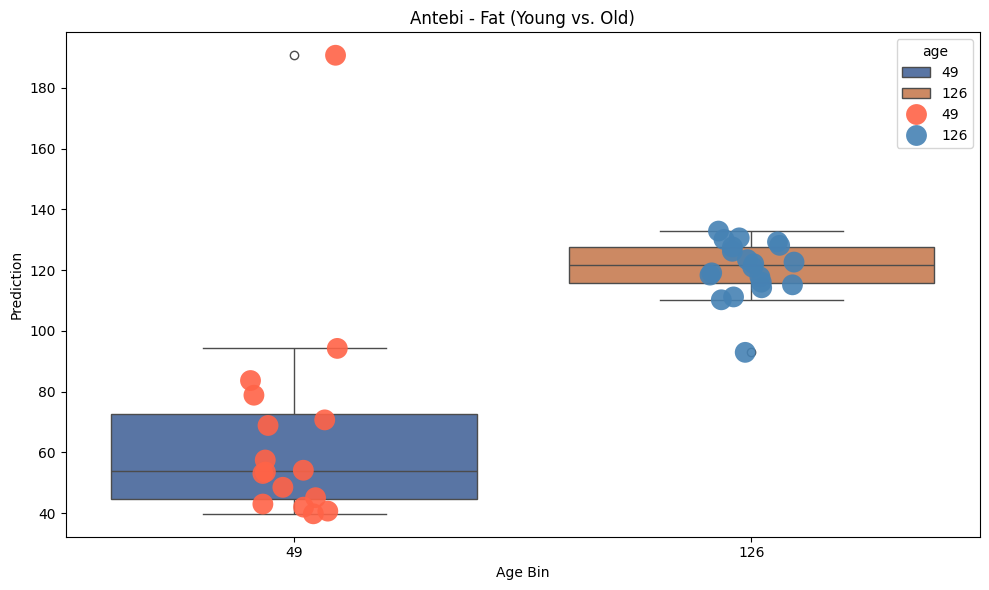

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_antebi, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_antebi,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Antebi - Fat (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_7w = df_prediction_antebi[df_prediction_antebi['age'] == 49]['y_pred']
group_18w = df_prediction_antebi[df_prediction_antebi['age'] == 126]['y_pred']

print("Group 7w size:", len(group_7w))
print("Group 18w size:", len(group_18w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_7w, group_18w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_7w, group_18w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 7w size: 16
Group 18w size: 20
Welch’s t-test p-value: 0.0000
Mann-Whitney U test p-value: 0.0000


In [ ]:
df_prediction_antebi_fed = df_prediction_antebi[df_prediction_antebi["feeding"] == "fed"]

df_prediction_antebi_fed.head(3)

,y_pred,age,feeding,genotype
young_fed_wt_fat_rep_4,48.485248,49,fed,wt
young_fed_mut_fat_rep_1,53.030812,49,fed,mut
young_fed_mut_fat_rep_2,78.800783,49,fed,mut


In [ ]:
df_prediction_antebi["feeding"].value_counts()

feeding
fed       18
fasted    18
Name: count, dtype: int64

In [ ]:
df_prediction_antebi_fed_young = df_prediction_antebi_fed[df_prediction_antebi_fed["age"] == 49]

df_prediction_antebi_fed_young.head(3)

,y_pred,age,feeding,genotype
young_fed_wt_fat_rep_4,48.485248,49,fed,wt
young_fed_mut_fat_rep_1,53.030812,49,fed,mut
young_fed_mut_fat_rep_2,78.800783,49,fed,mut


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

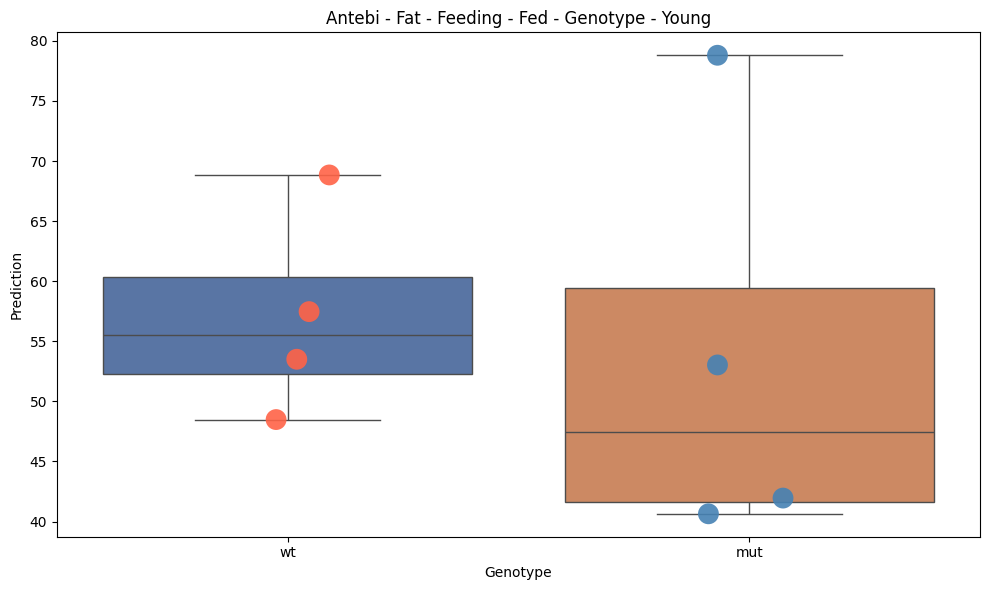

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_antebi_fed_young, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_antebi_fed_young,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Antebi - Fat - Feeding - Fed - Genotype - Young')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_antebi_fed["age"].value_counts()

age
126    10
49      8
Name: count, dtype: int64

In [ ]:
df_prediction_antebi_fed_old = df_prediction_antebi_fed[df_prediction_antebi_fed["age"] == 126]

df_prediction_antebi_fed_old.head(3)

,y_pred,age,feeding,genotype
old_fed_wt_fat_rep_4,111.151238,126,fed,wt
old_fed_wt_fat_rep_5,122.077055,126,fed,wt
old_fed_wt_fat_rep_3,130.592038,126,fed,wt


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

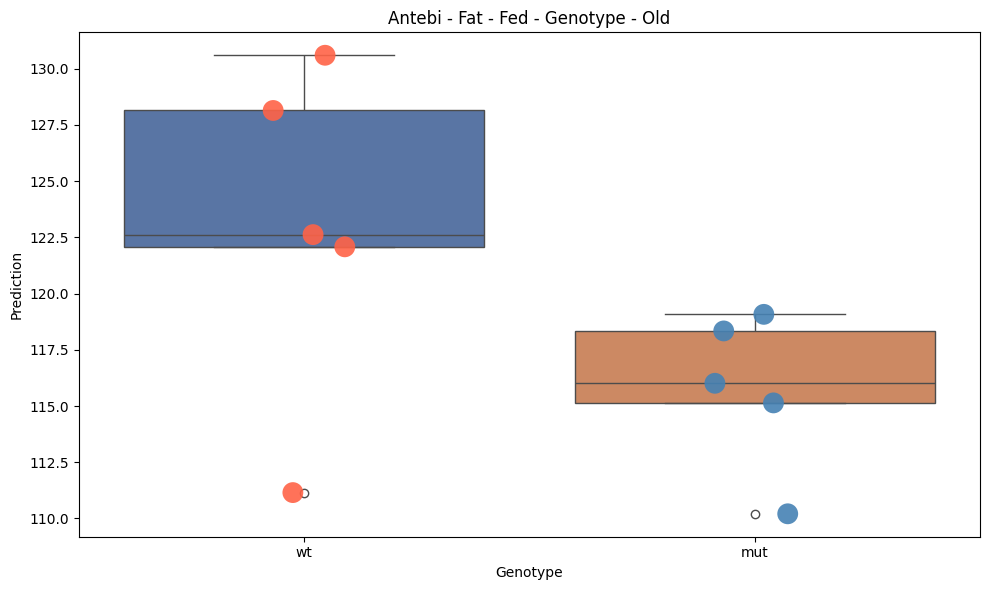

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_antebi_fed_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_antebi_fed_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Antebi - Fat - Fed - Genotype - Old')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_antebi_fasted = df_prediction_antebi[df_prediction_antebi["feeding"] == "fasted"]

df_prediction_antebi_fasted.head(3)

,y_pred,age,feeding,genotype
young_fasted_wt_fat_rep_1,190.704398,49,fasted,wt
young_fasted_wt_fat_rep_2,45.064380,49,fasted,wt
young_fasted_wt_fat_rep_3,54.091757,49,fasted,wt


In [ ]:
df_prediction_antebi_fasted_young = df_prediction_antebi_fasted[df_prediction_antebi_fasted["age"] == 49]

df_prediction_antebi_fasted_young.head(3)

,y_pred,age,feeding,genotype
young_fasted_wt_fat_rep_1,190.704398,49,fasted,wt
young_fasted_wt_fat_rep_2,45.064380,49,fasted,wt
young_fasted_wt_fat_rep_3,54.091757,49,fasted,wt


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

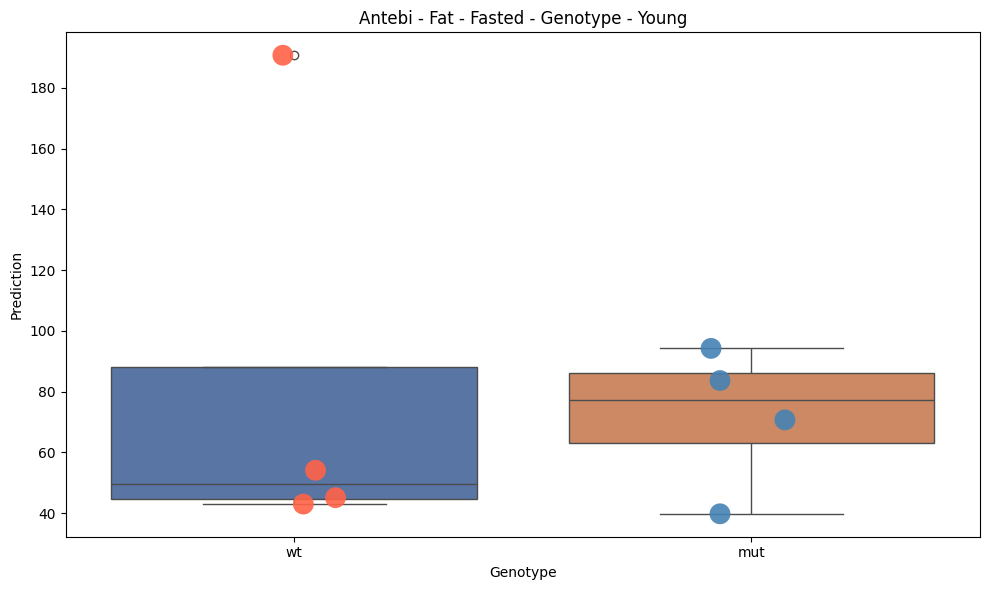

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_antebi_fasted_young, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_antebi_fasted_young,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Antebi - Fat - Fasted - Genotype - Young')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_antebi_fasted_old = df_prediction_antebi_fasted[df_prediction_antebi_fasted["age"] == 126]

df_prediction_antebi_fasted_old.head(3)

,y_pred,age,feeding,genotype
old_fasted_wt_fat_rep_1,92.910671,126,fasted,wt
old_fasted_wt_fat_rep_2,126.182037,126,fasted,wt
old_fasted_wt_fat_rep_3,114.160926,126,fasted,wt


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/tmp/ipykernel_430929/258889169.py:15: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  strip = sns.stripplot(
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(

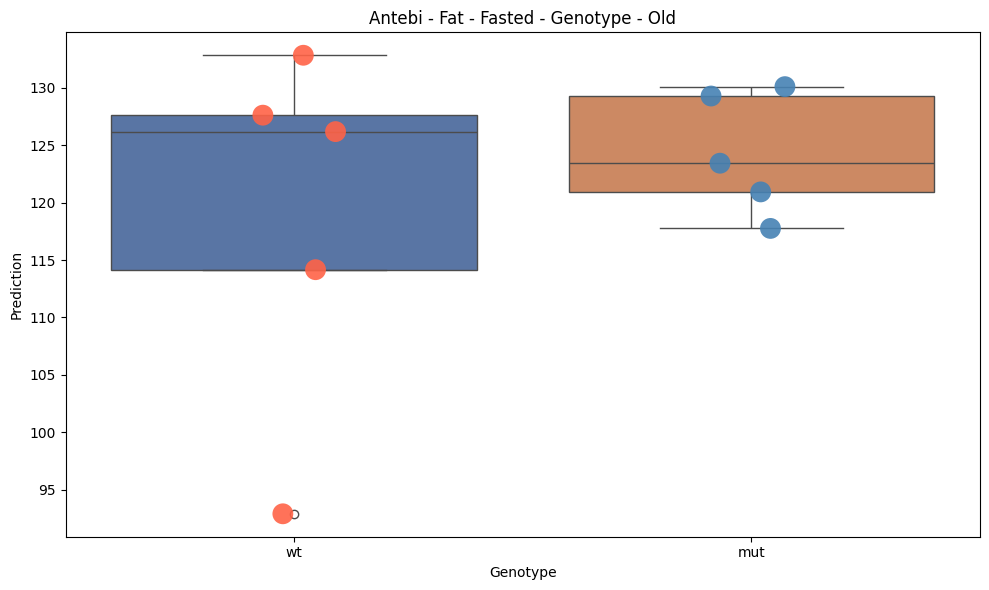

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_antebi_fasted_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_antebi_fasted_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Antebi - Fat - Fasted - Genotype - Old')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

## Male Only

In [ ]:
fat_df_male = fat_df[fat_df["sex"] == "M"]

fat_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,M,Fat,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,M,Fat,77
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266,M,Fat,103
B7_2,2024.601159,607.466027,159.363443,397.551814,323.867642,497.796561,714.565115,582.619038,418.971632,533.781854,...,156.793065,702.570017,133.659662,365.850484,3573.682367,217.625347,282.741592,M,Fat,102
B8_2,2079.848143,300.129985,168.494027,235.628366,211.933893,469.940372,655.547073,594.994532,494.951204,242.210163,...,72.399777,685.823343,130.319599,321.191739,1396.657519,147.432273,201.403016,M,Fat,152


In [ ]:
fat_df_male_age = fat_df_male.iloc[:,:-3]

fat_df_male_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,301.647333,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,407.861536,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,250.358741,75.107622,444.386765,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266
B7_2,2024.601159,607.466027,159.363443,397.551814,323.867642,497.796561,714.565115,582.619038,418.971632,533.781854,...,394.981436,135.373247,1021.296903,156.793065,702.570017,133.659662,365.850484,3573.682367,217.625347,282.741592
B8_2,2079.848143,300.129985,168.494027,235.628366,211.933893,469.940372,655.547073,594.994532,494.951204,242.210163,...,188.239421,98.726969,513.380238,72.399777,685.823343,130.319599,321.191739,1396.657519,147.432273,201.403016


In [ ]:
fat_df_male_age["age"] = fat_df_male["age_days"].tolist()

In [ ]:
fat_atlas_plus_antebi_male = pd.concat([fat_df_male_age, antebi_age], axis=0)

fat_atlas_plus_antebi_male

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,77
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,75.107622,444.386765,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266,103
B7_2,2024.601159,607.466027,159.363443,397.551814,323.867642,497.796561,714.565115,582.619038,418.971632,533.781854,...,135.373247,1021.296903,156.793065,702.570017,133.659662,365.850484,3573.682367,217.625347,282.741592,102
B8_2,2079.848143,300.129985,168.494027,235.628366,211.933893,469.940372,655.547073,594.994532,494.951204,242.210163,...,98.726969,513.380238,72.399777,685.823343,130.319599,321.191739,1396.657519,147.432273,201.403016,152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
old_fed_mut_fat_rep_3,2213.451674,168.927849,367.666496,196.254413,150.296101,259.602357,665.774465,493.120266,197.496530,170.169966,...,47.200429,2561.244305,59.621594,521.688947,59.621594,772.596488,1635.867483,2054.460757,642.174251,126
old_fed_mut_fat_rep_2,2968.565271,296.856527,544.690875,170.215899,156.598627,303.665163,724.438864,469.795880,269.621983,189.280079,...,43.575270,2765.667920,95.320903,528.350149,73.533268,811.589404,1423.004912,2233.232589,695.842593,126
old_fed_mut_fat_rep_1,1709.379013,266.895751,463.692424,177.065080,164.083769,282.473324,605.448338,497.963084,274.684538,200.431440,...,28.039631,2414.523819,103.850487,641.276756,105.408244,679.182184,1389.000261,1824.133801,619.987406,126
old_fed_wt_fat_rep_2,6815.124972,172.450387,473.523991,217.230322,97.181986,264.868551,619.296971,459.232523,183.883562,111.473455,...,60.024168,1931.253784,82.890518,387.775180,22.866350,674.557316,1646.377178,1296.712580,637.399498,126


In [ ]:
fat_atlas_antebi_male_data = fat_atlas_plus_antebi_male.values

In [ ]:
X, y = fat_atlas_antebi_male_data[:,:-1], fat_atlas_antebi_male_data[:,-1]

In [ ]:
# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Set a seed for reproducibility
seed = 42

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1, return_train_score=True)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

### Best parameters

### alpha = 0.01, l1_ratio =  0.7000000000000001

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.01, l1_ratio=0.7000000000000001, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 16.305
Pearson correlation: 0.828
R-squared: 0.679
Average number of non-zero coefficients: 336.32


In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': fat_atlas_plus_antebi_male["age"].tolist(),
}, index=fat_atlas_plus_antebi_male.index.tolist())

df_prediction.head(10)

,y_pred,age
A5_2,38.272262,52
A6_2,92.187142,77
A8_2,111.363557,103
B7_2,104.931419,102
B8_2,123.005072,152
C5_2,90.431777,52
C6_2,51.559248,49
C7_2,80.818389,78
D6_2,127.971817,133
E6_2,91.867226,47


In [ ]:
df_prediction_antebi = df_prediction.loc[antebi_age.index.tolist(), ]

df_prediction_antebi.head(5)

,y_pred,age
young_fed_wt_fat_rep_4,58.029690,49
young_fasted_wt_fat_rep_1,152.925296,49
young_fasted_wt_fat_rep_2,48.879365,49
young_fasted_wt_fat_rep_3,54.870874,49
young_fasted_wt_fat_rep_4,36.354043,49


In [ ]:
df_prediction_antebi["feeding"] = df_metadata["feeding"].tolist()
df_prediction_antebi["genotype"] = df_metadata["genotype"].tolist()

In [ ]:
df_prediction_antebi["age"].value_counts()

age
126    20
49     16
Name: count, dtype: int64

In [ ]:
df_prediction_antebi.to_csv("./df_prediction_sex_specific_antebi_male.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

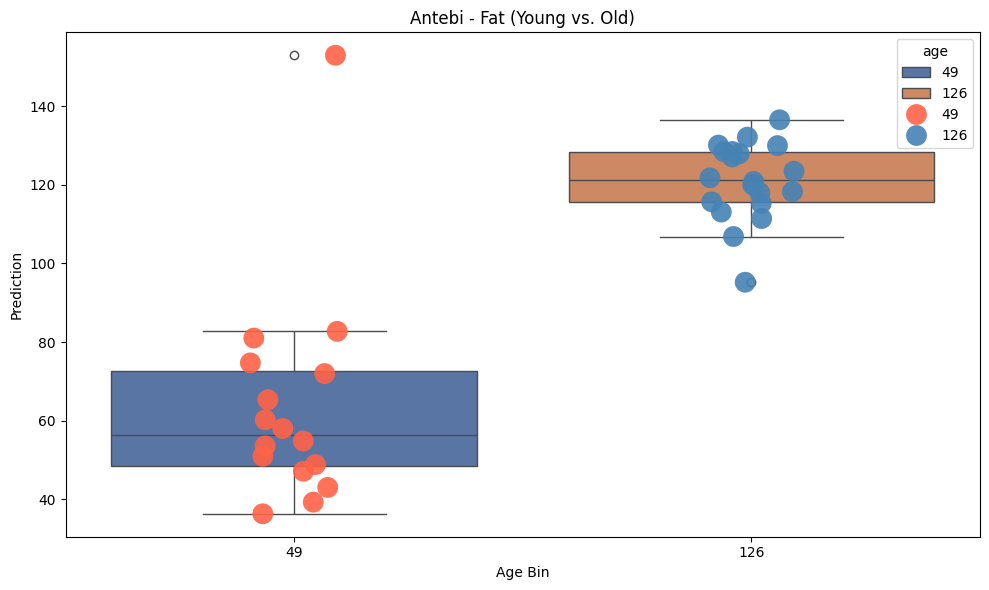

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_antebi, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_antebi,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Antebi - Fat (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_7w = df_prediction_antebi[df_prediction_antebi['age'] == 49]['y_pred']
group_18w = df_prediction_antebi[df_prediction_antebi['age'] == 126]['y_pred']

print("Group 7w size:", len(group_7w))
print("Group 18w size:", len(group_18w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_7w, group_18w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_7w, group_18w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 7w size: 16
Group 18w size: 20
Welch’s t-test p-value: 0.0000
Mann-Whitney U test p-value: 0.0000


In [ ]:
df_prediction_antebi_fed = df_prediction_antebi[df_prediction_antebi["feeding"] == "fed"]

df_prediction_antebi_fed.head(3)

,y_pred,age,feeding,genotype
young_fed_wt_fat_rep_4,58.029690,49,fed,wt
young_fed_mut_fat_rep_1,50.980325,49,fed,mut
young_fed_mut_fat_rep_2,81.024322,49,fed,mut


In [ ]:
df_prediction_antebi["feeding"].value_counts()

feeding
fed       18
fasted    18
Name: count, dtype: int64

In [ ]:
df_prediction_antebi_fed_young = df_prediction_antebi_fed[df_prediction_antebi_fed["age"] == 49]

df_prediction_antebi_fed_young.head(3)

,y_pred,age,feeding,genotype
young_fed_wt_fat_rep_4,58.029690,49,fed,wt
young_fed_mut_fat_rep_1,50.980325,49,fed,mut
young_fed_mut_fat_rep_2,81.024322,49,fed,mut


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

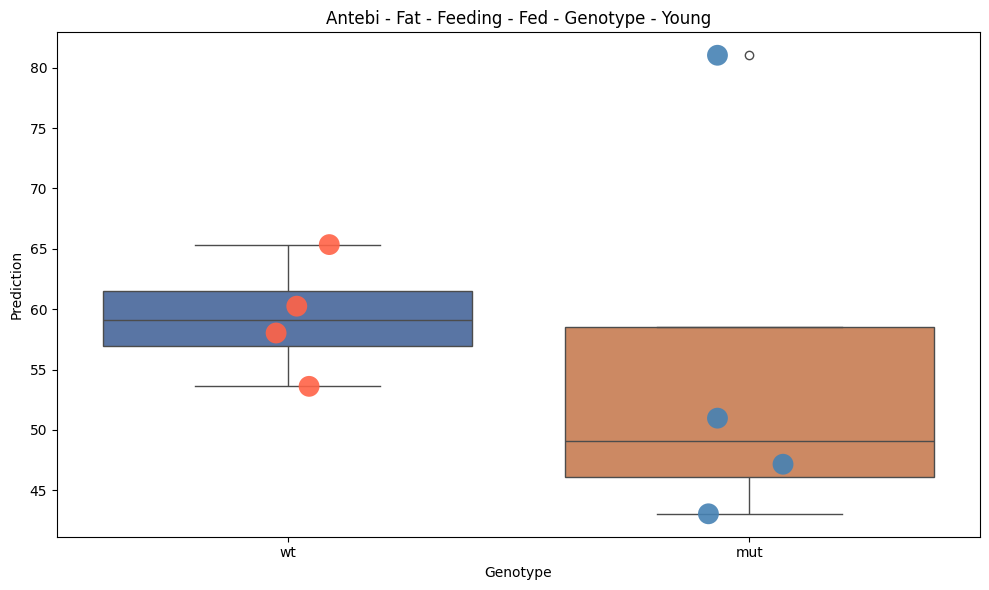

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_antebi_fed_young, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_antebi_fed_young,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Antebi - Fat - Feeding - Fed - Genotype - Young')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_antebi_fed["age"].value_counts()

age
126    10
49      8
Name: count, dtype: int64

In [ ]:
df_prediction_antebi_fed_old = df_prediction_antebi_fed[df_prediction_antebi_fed["age"] == 126]

df_prediction_antebi_fed_old.head(3)

,y_pred,age,feeding,genotype
old_fed_wt_fat_rep_4,106.847818,126,fed,wt
old_fed_wt_fat_rep_5,120.834898,126,fed,wt
old_fed_wt_fat_rep_3,127.889745,126,fed,wt


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

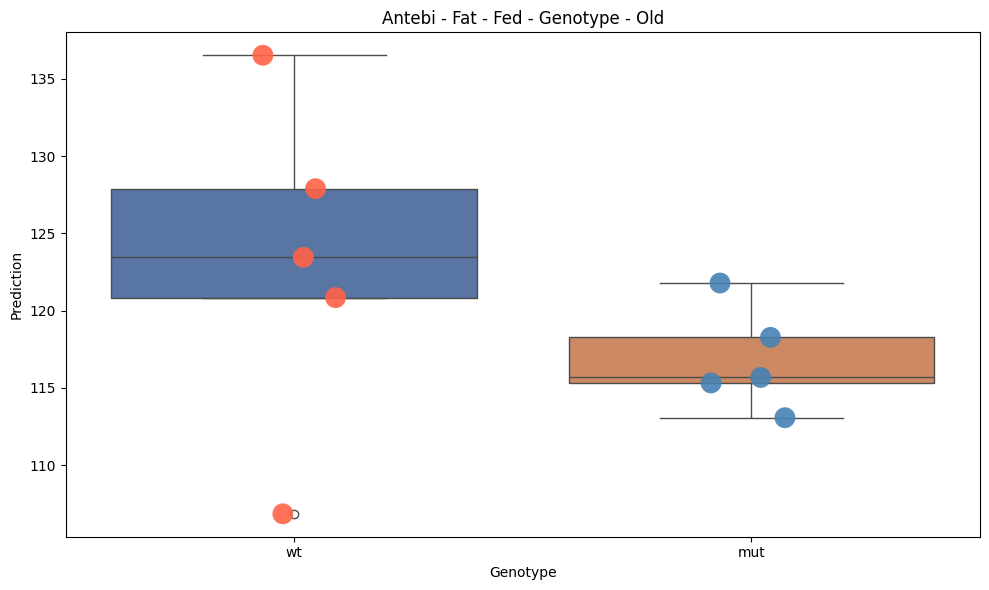

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_antebi_fed_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_antebi_fed_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Antebi - Fat - Fed - Genotype - Old')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_antebi_fasted = df_prediction_antebi[df_prediction_antebi["feeding"] == "fasted"]

df_prediction_antebi_fasted.head(3)

,y_pred,age,feeding,genotype
young_fasted_wt_fat_rep_1,152.925296,49,fasted,wt
young_fasted_wt_fat_rep_2,48.879365,49,fasted,wt
young_fasted_wt_fat_rep_3,54.870874,49,fasted,wt


In [ ]:
df_prediction_antebi_fasted_young = df_prediction_antebi_fasted[df_prediction_antebi_fasted["age"] == 49]

df_prediction_antebi_fasted_young.head(3)

,y_pred,age,feeding,genotype
young_fasted_wt_fat_rep_1,152.925296,49,fasted,wt
young_fasted_wt_fat_rep_2,48.879365,49,fasted,wt
young_fasted_wt_fat_rep_3,54.870874,49,fasted,wt


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/tmp/ipykernel_430929/442849688.py:15: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  strip = sns.stripplot(
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


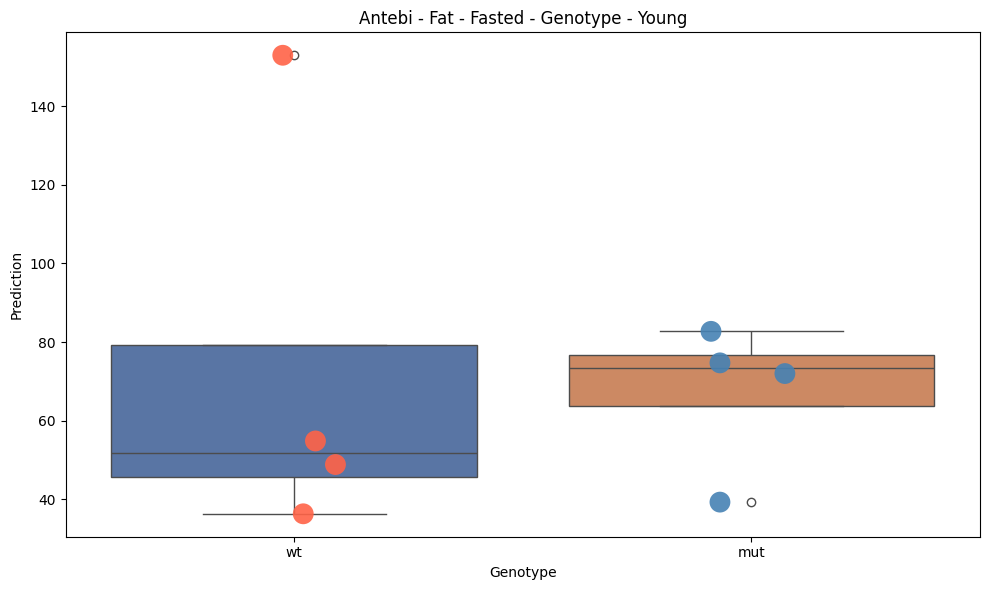

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_antebi_fasted_young, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_antebi_fasted_young,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Antebi - Fat - Fasted - Genotype - Young')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
df_prediction_antebi_fasted_old = df_prediction_antebi_fasted[df_prediction_antebi_fasted["age"] == 126]

df_prediction_antebi_fasted_old.head(3)

,y_pred,age,feeding,genotype
old_fasted_wt_fat_rep_1,95.220251,126,fasted,wt
old_fasted_wt_fat_rep_2,127.058044,126,fasted,wt
old_fasted_wt_fat_rep_3,111.418815,126,fasted,wt


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

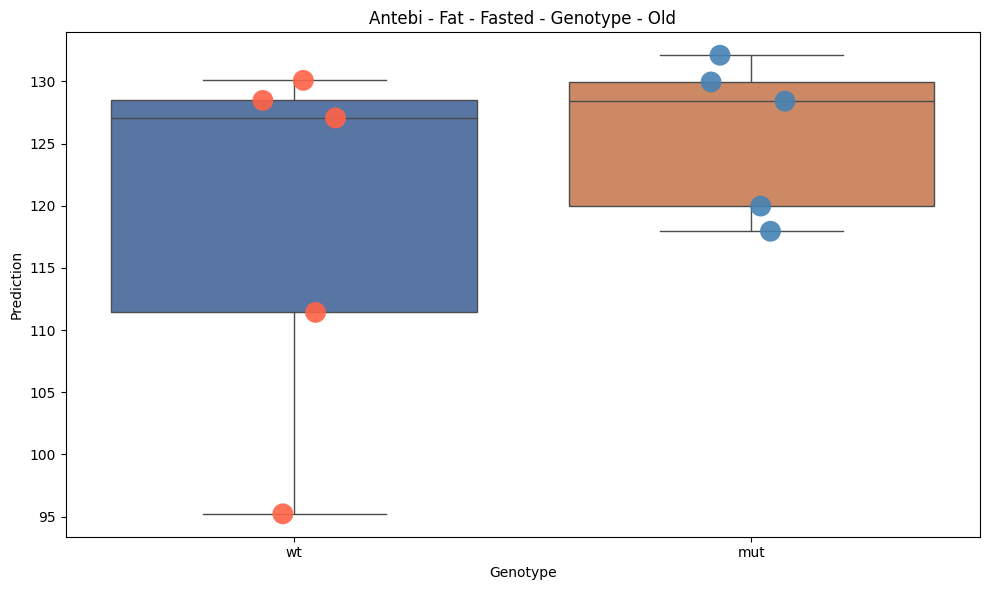

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_antebi_fasted_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_antebi_fasted_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Antebi - Fat - Fasted - Genotype - Old')
plt.xlabel('Genotype')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()